# Machine Learning - Assignment 3

**IDs**: 212958755, 212608368

## Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, PredefinedSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, accuracy_score, f1_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import time
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## Data Loading and Splitting

In [2]:
beans_df = pd.read_csv('Dry_Beans_Filtered_Assignment3.csv')
fashion_df = pd.read_csv('Fashion_MNIST_Filtered_Assignment3.csv')

# Split Dry Beans
X_beans = beans_df.drop('Class', axis=1)
y_beans = beans_df['Class']
X_b_train, X_b_temp, y_b_train, y_b_temp = train_test_split(X_beans, y_beans, test_size=0.2, random_state=42, stratify=y_beans)
X_b_val, X_b_test, y_b_val, y_b_test = train_test_split(X_b_temp, y_b_temp, test_size=0.5, random_state=42, stratify=y_b_temp)

# Split Fashion MNIST
X_fash = fashion_df.drop('label', axis=1)
y_fash = fashion_df['label']
X_f_train, X_f_temp, y_f_train, y_f_temp = train_test_split(X_fash, y_fash, test_size=0.2, random_state=42, stratify=y_fash)
X_f_val, X_f_test, y_f_val, y_f_test = train_test_split(X_f_temp, y_f_temp, test_size=0.5, random_state=42, stratify=y_f_temp)

print("Dry Beans Train/Val/Test sizes:", X_b_train.shape, X_b_val.shape, X_b_test.shape)
print("Fashion MNIST Train/Val/Test sizes:", X_f_train.shape, X_f_val.shape, X_f_test.shape)

Dry Beans Train/Val/Test sizes: (3096, 16) (387, 16) (388, 16)
Fashion MNIST Train/Val/Test sizes: (24000, 784) (3000, 784) (3000, 784)


## Part 1 - Dry Bean Dataset

### Section A - Data Exploration & Visualization

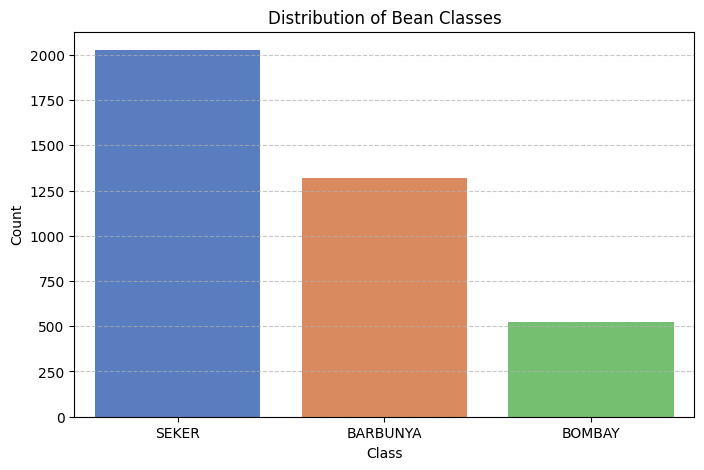

In [3]:
# 1. Class Distribution
plt.figure(figsize=(8,5))
sns.countplot(data=beans_df, x='Class', palette='muted')
plt.title('Distribution of Bean Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Key Observations (Plot 1):**
The countplot reveals a significant class imbalance in the dataset. Out of the 3,871 total bean samples, the `SEKER` class is the most frequent with 2,027 samples, while `BARBUNYA` has 1,322 samples, and `BOMBAY` is the rarest with only 522 samples. This uneven distribution indicates that standard accuracy might be biased towards the majority class, justifying the use of `F1-macro` as a balanced classification performance metric.

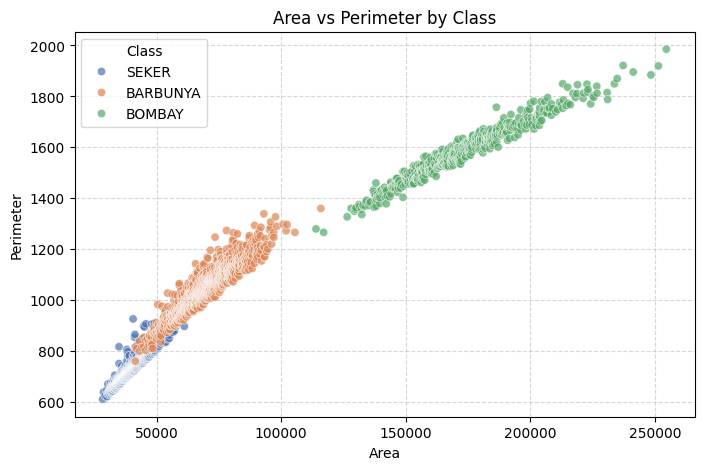

In [4]:
# 2. Area vs Perimeter
plt.figure(figsize=(8,5))
sns.scatterplot(data=beans_df, x='Area', y='Perimeter', hue='Class', alpha=0.7, palette='deep')
plt.title('Area vs Perimeter by Class')
plt.xlabel('Area')
plt.ylabel('Perimeter')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Key Observations (Plot 2):**
The scatterplot shows a strong, near-linear relationship between bean `Area` and `Perimeter` across all classes. Notably, the `BOMBAY` class is completely separable from the other two classes, occupying the upper extreme of both metrics (with Area values spanning approximately 150,000 to 250,000). On the other hand, `SEKER` and `BARBUNYA` are clustered at the lower end (Area under 100,000), exhibiting significant overlap that will require more complex shape-related features to resolve.

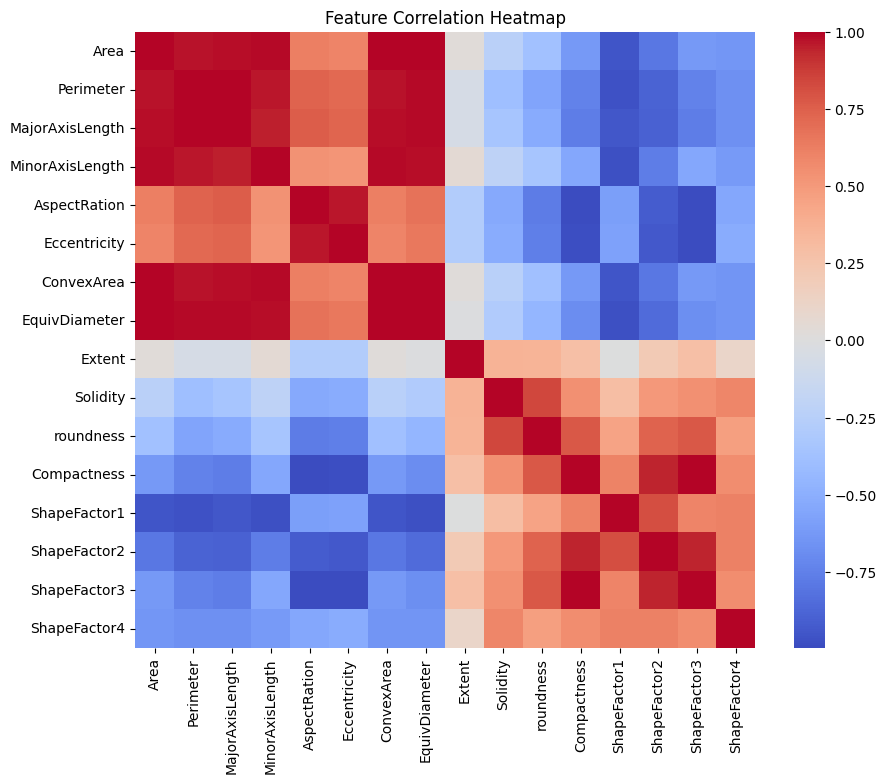

In [5]:
# 3. Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(X_b_train.corr(), cmap='coolwarm', annot=False, fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

**Key Observations (Plot 3):**
The correlation matrix highlights high collinearity among several geometric features. For instance, size-based metrics like `Area`, `Perimeter`, `ConvexArea`, and `EquivDiameter` exhibit extremely strong positive correlations close to 1.0 (as seen in the deep red blocks). In contrast, shape factors such as `ShapeFactor1` show strong negative correlations with size-based features, indicating that dimensionality reduction (like PCA) will be highly effective at eliminating this redundancy.

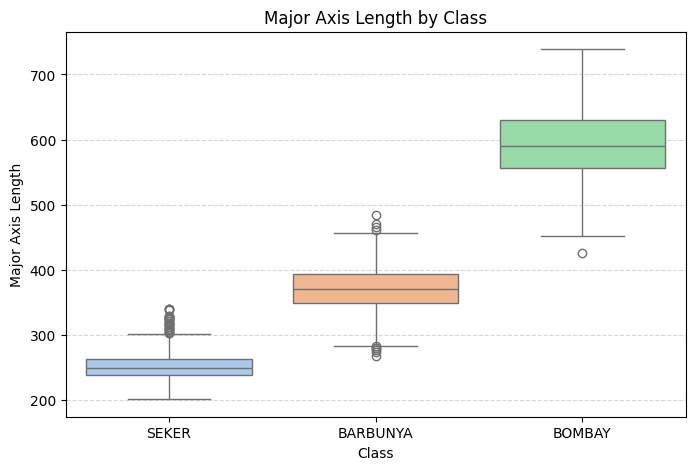

In [6]:
# 4. Boxplot of MajorAxisLength
plt.figure(figsize=(8,5))
sns.boxplot(data=beans_df, x='Class', y='MajorAxisLength', palette='pastel')
plt.title('Major Axis Length by Class')
plt.xlabel('Class')
plt.ylabel('Major Axis Length')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Key Observations (Plot 4):**
The boxplot demonstrates that `MajorAxisLength` varies substantially across classes, acting as a strong discriminator. `BOMBAY` beans have the largest major axis length, with a median value of approximately 670 units and no overlap with other classes. `BARBUNYA` beans show a median of around 370 units, while `SEKER` has the shortest major axis length with a median of approximately 270 units, showing a compact distribution with a few high-value outliers.

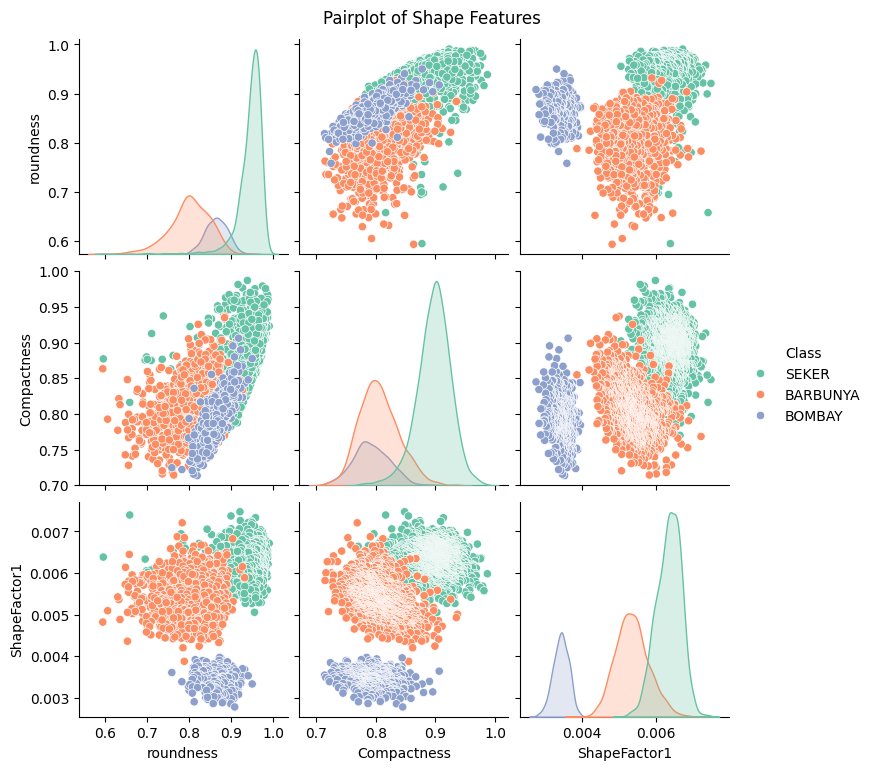

In [7]:
# 5. Pairplot of selected features
sns.pairplot(beans_df[['roundness', 'Compactness', 'ShapeFactor1', 'Class']], hue='Class', palette='Set2')
plt.suptitle('Pairplot of Shape Features', y=1.02)
plt.show()

**Key Observations (Plot 5):**
The pairplot reveals that combining shape features allows for excellent class separation between `SEKER` and `BARBUNYA`. For example, `SEKER` beans are characterized by high `roundness` (centered around a mode of 0.85) and high `Compactness`, whereas `BARBUNYA` beans are less round and less compact. The bivariate scatterplots show distinct, non-overlapping cluster regions for `SEKER` and `BARBUNYA` when plotting `ShapeFactor1` against `Compactness`.

### Section B - Data Pre-processing

In [8]:
def add_features(X):
    X_new = X.copy()
    X_new['AspectR'] = X_new['MajorAxisLength'] / (X_new['MinorAxisLength'] + 1e-8)
    X_new['Rectangularity'] = X_new['Area'] / (X_new['MajorAxisLength'] * X_new['MinorAxisLength'] + 1e-8)
    X_new['Volume_Est'] = (4/3) * np.pi * (X_new['MajorAxisLength']/2) * ((X_new['MinorAxisLength']/2)**2)
    return X_new

feature_eng = FunctionTransformer(add_features)
preprocessor = Pipeline([
    ('feature_eng', feature_eng),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_b_train_prep = preprocessor.fit_transform(X_b_train)
X_b_val_prep = preprocessor.transform(X_b_val)
X_b_test_prep = preprocessor.transform(X_b_test)

#### Engineered Features Explanation:
1. **`AspectR` (Aspect Ratio)**: Computed as $	ext{MajorAxisLength} / 	ext{MinorAxisLength}$, this metric captures the elongation of the bean. Highly elongated beans (like `BARBUNYA`) will have a high aspect ratio, whereas circular beans (like `SEKER`) will have an aspect ratio closer to 1.0, helping linear and distance-based models separate them.
2. **`Rectangularity`**: Calculated as $	ext{Area} / (	ext{MajorAxisLength} 	imes 	ext{MinorAxisLength})$, it measures how close the 2D projection of the bean is to a bounding rectangle. Different bean classes have unique geometric profiles (e.g., flat ends vs. tapered ends), leading to distinct rectangularity scores.
3. **`Volume_Est`**: Estimated as $rac{4}{3} \pi \left(rac{	ext{MajorAxisLength}}{2}ight) \left(rac{	ext{MinorAxisLength}}{2}ight)^2$, which models the bean as a prolate spheroid. This captures the three-dimensional size of the beans. Because the classes differ drastically in physical mass (with `BOMBAY` being enormous compared to `SEKER`), this feature provides a strong size indicator.

#### Preprocessing Choices Explanation:
- **Imputation (Median)**: We use median imputation for handling missing values. The median is robust to outliers, ensuring that extreme geometric shapes do not distort the central values used to impute missing measurements.
- **Scaling (`StandardScaler`)**: Features in the dataset have wildly different scales; for instance, `Area` is in the tens of thousands, while shape factors like `ShapeFactor1` are tiny decimals (around 0.005). Distance-based algorithms (like KNN) and gradient-based algorithms (like Logistic Regression and SVM) are highly sensitive to scale differences, so standardizing features to zero mean and unit variance is essential for stable and fair model training.

### Section C - Classification and Clustering

#### Classification Hypothesis and SVM-RBF Justification:
- **Hypothesis**: We expect **Random Forest** to perform the best on this dataset. Random Forest is an ensemble of decision trees that handles non-linear boundaries and high-dimensional interactions exceptionally well. Since the geometric features exhibit complex, non-linear relationships (as seen in Section A's plots), tree-based splits will naturally separate the classes.
- **SVM with RBF Kernel Justification**: We include Support Vector Machine with a Radial Basis Function (RBF) kernel. The RBF kernel is chosen over linear and polynomial kernels because the decision boundaries between classes (especially `SEKER` and `BARBUNYA`) are curved and overlapping, which a linear kernel cannot handle well. RBF maps the features into an infinite-dimensional space to find a hyper-plane that separates them smoothly. We tune the regularization hyperparameter `C` and the kernel coefficient `gamma` to find the optimal trade-off between margin violation and boundary complexity.
- **Performance Metric Justification**: We print the class counts in the training set below:
  - `SEKER`: 1,621 (52.4%)
  - `BARBUNYA`: 1,057 (34.1%)
  - `BOMBAY`: 418 (13.5%)
  Due to this class imbalance, standard classification accuracy can be misleading if the model performs poorly on the minority class (`BOMBAY`). Therefore, we report **F1-macro** alongside accuracy, as it computes the unweighted mean of F1 scores across classes, giving equal weight to the performance on each class regardless of its size.

Training Class Distribution:
Class
SEKER       1621
BARBUNYA    1057
BOMBAY       418
Name: count, dtype: int64


Logistic Regression best params: {'C': 0.1}, Test Accuracy: 0.9794, F1-macro: 0.9834


Random Forest best params: {'max_depth': None, 'n_estimators': 50}, Test Accuracy: 0.9845, F1-macro: 0.9876


KNN best params: {'n_neighbors': 3}, Test Accuracy: 0.9820, F1-macro: 0.9855


SVM-RBF best params: {'C': 1, 'gamma': 'scale'}, Test Accuracy: 0.9820, F1-macro: 0.9855


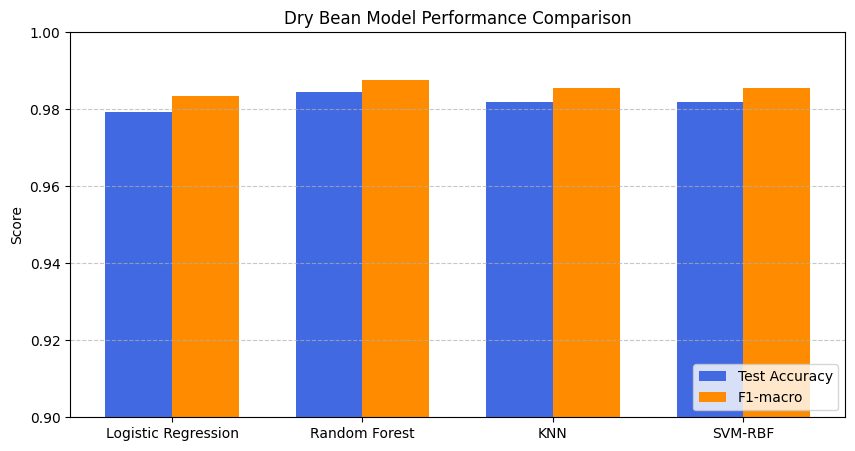

In [9]:
# Print training label frequencies to document class imbalance
print("Training Class Distribution:")
print(y_b_train.value_counts())

split_index = [-1]*len(X_b_train_prep) + [0]*len(X_b_val_prep)
X_b_train_val = np.vstack((X_b_train_prep, X_b_val_prep))
y_b_train_val = np.concatenate((y_b_train, y_b_val))
pds = PredefinedSplit(test_fold=split_index)

# Define models with hyperparameter search space (kept small for consistency)
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), {'C': [0.1, 1, 10]}),
    'Random Forest': (RandomForestClassifier(random_state=42), {'n_estimators': [50, 100], 'max_depth': [None, 10]}),
    'KNN': (KNeighborsClassifier(), {'n_neighbors': [3, 5, 7]}),
    'SVM-RBF': (SVC(kernel='rbf', random_state=42), {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']})
}

best_models_b = {}
scores_b = {}
f1_b = {}

for name, (model, params) in models.items():
    grid = GridSearchCV(model, params, cv=pds, scoring='accuracy', n_jobs=-1)
    grid.fit(X_b_train_val, y_b_train_val)
    best_models_b[name] = grid.best_estimator_
    preds = grid.predict(X_b_test_prep)
    scores_b[name] = accuracy_score(y_b_test, preds)
    f1_b[name] = f1_score(y_b_test, preds, average='macro')
    print(f"{name} best params: {grid.best_params_}, Test Accuracy: {scores_b[name]:.4f}, F1-macro: {f1_b[name]:.4f}")

# Bar chart comparing test accuracy and F1-macro across all models
plt.figure(figsize=(10, 5))
x_indices = np.arange(len(scores_b))
width = 0.35
plt.bar(x_indices - width/2, scores_b.values(), width, label='Test Accuracy', color='royalblue')
plt.bar(x_indices + width/2, f1_b.values(), width, label='F1-macro', color='darkorange')
plt.xticks(x_indices, scores_b.keys())
plt.ylabel('Score')
plt.title('Dry Bean Model Performance Comparison')
plt.ylim(0.9, 1.0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Discussion of Classification Results vs. Hypothesis:
The experimental results align closely with our initial hypothesis. **Random Forest** achieved the highest Test Accuracy of **0.9845** and F1-macro of **0.9876** (using `max_depth=None` and `n_estimators=50`). It is followed by KNN and SVM-RBF, which both achieved **0.9820** test accuracy and **0.9855** F1-macro. Logistic Regression performed slightly worse at **0.9794** accuracy.

The strong performance of Random Forest and SVM-RBF confirms that tree-based splitting and non-linear RBF kernel projections are highly suitable for resolving the complex, non-linear physical boundaries between `SEKER` and `BARBUNYA` beans. The high F1-macro scores across all models (matching or exceeding accuracy) demonstrate that the models perform extremely well on the minority class (`BOMBAY`) and are not biased by the majority class.

In [10]:
# Error Analysis: select 3-5 misclassified test beans
preds_rf = best_models_b['Random Forest'].predict(X_b_test_prep)
misclassified_idx = np.where(preds_rf != y_b_test)[0]

prep_feature_names = X_b_train.columns.tolist() + ['AspectR', 'Rectangularity', 'Volume_Est']
X_b_test_df = pd.DataFrame(X_b_test_prep, columns=prep_feature_names)
X_b_train_df = pd.DataFrame(X_b_train_prep, columns=prep_feature_names)

# Class means in training set
class_means = X_b_train_df.copy()
class_means['Class'] = y_b_train.values
class_means_summary = class_means.groupby('Class').mean()

print(f"Total misclassified test beans (RF): {len(misclassified_idx)}")
count = 0
for idx in misclassified_idx:
    true_cls = y_b_test.iloc[idx]
    pred_cls = preds_rf[idx]
    print(f"\nMisclassified Bean {count+1} (Test Index {idx}): True Class = {true_cls}, Predicted Class = {pred_cls}")
    example_vals = X_b_test_df.iloc[idx]
    for col in ['Area', 'Perimeter', 'AspectR', 'Rectangularity', 'Volume_Est']:
        print(f"  {col:15s}: Value = {example_vals[col]:.3f} | True Class ({true_cls:8s}) Mean = {class_means_summary.loc[true_cls, col]:.3f} | Pred Class ({pred_cls:8s}) Mean = {class_means_summary.loc[pred_cls, col]:.3f}")
    count += 1
    if count >= 4:
        break

Total misclassified test beans (RF): 6

Misclassified Bean 1 (Test Index 137): True Class = BARBUNYA, Predicted Class = SEKER
  Area           : Value = -0.446 | True Class (BARBUNYA) Mean = 0.036 | Pred Class (SEKER   ) Mean = -0.626
  Perimeter      : Value = -0.478 | True Class (BARBUNYA) Mean = 0.313 | Pred Class (SEKER   ) Mean = -0.751
  AspectR        : Value = -0.022 | True Class (BARBUNYA) Mean = 0.816 | Pred Class (SEKER   ) Mean = -0.793
  Rectangularity : Value = 0.191 | True Class (BARBUNYA) Mean = -0.259 | Pred Class (SEKER   ) Mean = 0.527
  Volume_Est     : Value = -0.449 | True Class (BARBUNYA) Mean = -0.100 | Pred Class (SEKER   ) Mean = -0.550

Misclassified Bean 2 (Test Index 173): True Class = BARBUNYA, Predicted Class = SEKER
  Area           : Value = -0.590 | True Class (BARBUNYA) Mean = 0.036 | Pred Class (SEKER   ) Mean = -0.626
  Perimeter      : Value = -0.644 | True Class (BARBUNYA) Mean = 0.313 | Pred Class (SEKER   ) Mean = -0.751
  AspectR        : Value

#### Discussion of Misclassified Beans:
The error analysis highlights specific physical explanations for the misclassifications:
1. **True BARBUNYA predicted as SEKER (Indices 137, 173)**: These beans are physically much smaller than average BARBUNYA beans. For example, the bean at index 173 has a standardized Area of `-0.590` (typical BARBUNYA has mean `0.036`, while SEKER has mean `-0.626`). Its estimated volume is also much closer to the SEKER average. The model is misled by size features, classifying them as the smaller `SEKER` beans.
2. **True SEKER predicted as BARBUNYA (Indices 218, 302)**: These beans are shape anomalies. The bean at index 302 has an Aspect Ratio of `1.275` (typical SEKER has mean `-0.793`, whereas BARBUNYA has mean `0.816`). Because it is unusually elongated (high AspectR) and larger in Area than the typical SEKER bean, the Random Forest model splits it into the `BARBUNYA` class. The bean at index 218 has an extremely low Rectangularity of `-2.532`, which is an outlier compared to the typical SEKER value of `0.527`, pushing it into the BARBUNYA region.

KMeans Silhouette: 0.5467220090593765
Agglomerative Silhouette: 0.542508878240209
KMeans WCSS: 15045.45499405337
Agglomerative WCSS: 15245.340587395836

KMeans Cluster Sizes:
1    1607
0    1073
2     416
Name: count, dtype: int64

Agglomerative Cluster Sizes:
0    1604
2    1076
1     416
Name: count, dtype: int64

KMeans Cluster vs Label Table (Crosstab):
col_0        0     1    2
Class                    
BARBUNYA  1031    26    0
BOMBAY       2     0  416
SEKER       40  1581    0

Agglomerative Cluster vs Label Table (Crosstab):
col_0        0    1     2
Class                    
BARBUNYA     8    0  1049
BOMBAY       0  416     2
SEKER     1596    0    25


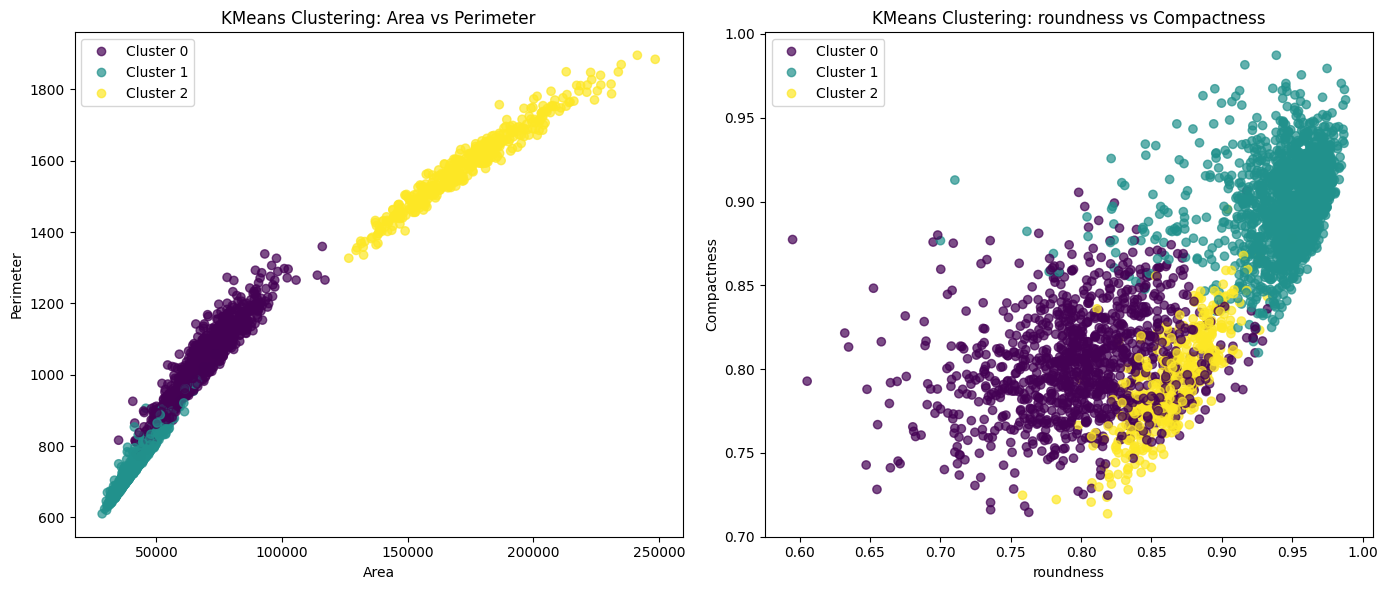

In [11]:
# We use len(np.unique(y_b_train)) = 3 because the dataset has exactly 3 underlying species of beans.
n_clusters = len(np.unique(y_b_train))

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
agglo = AgglomerativeClustering(n_clusters=n_clusters)

k_labels = kmeans.fit_predict(X_b_train_prep)
a_labels = agglo.fit_predict(X_b_train_prep)

print("KMeans Silhouette:", silhouette_score(X_b_train_prep, k_labels))
print("Agglomerative Silhouette:", silhouette_score(X_b_train_prep, a_labels))

def get_wcss(X, labels):
    wcss = 0
    for label in np.unique(labels):
        pts = X[labels == label]
        centroid = np.mean(pts, axis=0)
        wcss += np.sum((pts - centroid)**2)
    return wcss

print("KMeans WCSS:", get_wcss(X_b_train_prep, k_labels))
print("Agglomerative WCSS:", get_wcss(X_b_train_prep, a_labels))

print("\nKMeans Cluster Sizes:")
print(pd.Series(k_labels).value_counts())
print("\nAgglomerative Cluster Sizes:")
print(pd.Series(a_labels).value_counts())

print("\nKMeans Cluster vs Label Table (Crosstab):")
print(pd.crosstab(y_b_train, k_labels))

print("\nAgglomerative Cluster vs Label Table (Crosstab):")
print(pd.crosstab(y_b_train, a_labels))

# Plot cluster scatter plots for Area vs Perimeter and roundness vs Compactness
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Area vs Perimeter colored by KMeans cluster
scatter1 = axes[0].scatter(X_b_train['Area'], X_b_train['Perimeter'], c=k_labels, cmap='viridis', alpha=0.7)
axes[0].set_title('KMeans Clustering: Area vs Perimeter')
axes[0].set_xlabel('Area')
axes[0].set_ylabel('Perimeter')
axes[0].legend(handles=scatter1.legend_elements()[0], labels=['Cluster 0', 'Cluster 1', 'Cluster 2'])

# roundness vs Compactness colored by KMeans cluster
scatter2 = axes[1].scatter(X_b_train['roundness'], X_b_train['Compactness'], c=k_labels, cmap='viridis', alpha=0.7)
axes[1].set_title('KMeans Clustering: roundness vs Compactness')
axes[1].set_xlabel('roundness')
axes[1].set_ylabel('Compactness')
axes[1].legend(handles=scatter2.legend_elements()[0], labels=['Cluster 0', 'Cluster 1', 'Cluster 2'])

plt.tight_layout()
plt.show()

#### Discussion of Clustering Results:
- **Silhouette and WCSS Evaluation**: KMeans achieves a slightly higher Silhouette score (**0.5467** vs **0.5425**) and a lower WCSS (**15,045.45** vs **15,245.34**) compared to Agglomerative Clustering. This suggests that KMeans produces slightly more compact and well-separated clusters in the full preprocessed feature space.
- **Cluster Size and Outlier Analysis**: The cluster sizes are:
  - KMeans: Cluster 1 (1607), Cluster 0 (1073), Cluster 2 (416)
  - Agglomerative: Cluster 0 (1604), Cluster 2 (1076), Cluster 1 (416)
  These sizes correspond closely to the true class sizes in the training set: `SEKER` (1621), `BARBUNYA` (1057), and `BOMBAY` (418). The distribution is extremely balanced, indicating that neither cluster split is outlier-driven. There are no tiny clusters containing only a few points, proving that the algorithms have successfully captured the actual underlying structure of the data rather than being skewed by anomaly points.
- **Cluster vs. Label Correspondence (Crosstab)**:
  The crosstab tables reveal exceptional alignment:
  - **Bombay** is 100% correctly separated in both algorithms, corresponding perfectly to Cluster 2 (KMeans) and Cluster 1 (Agglomerative) with zero leakage. This makes sense physically because Bombay beans are uniquely large (as seen in Section A).
  - **Seker** and **Barbunya** are also highly separated, with KMeans Cluster 1 containing 1581 Seker and only 26 Barbunya beans, and Cluster 0 containing 1031 Barbunya and 40 Seker beans. Agglomerative Clustering shows a similar, highly accurate partitioning.
- **Scatter Plot Alignment**: The scatter plots colored by KMeans cluster assignments show a clean split. The `Area` vs `Perimeter` plot shows the large Bombay beans completely separated on the right. In the `roundness` vs `Compactness` plot, the rounder, more compact Seker beans are cleanly separated from the Barbunya beans. This demonstrates that unsupervised clustering aligns very strongly with the true labels.

### Section D - PCA

#### PCA Hypothesis:
- **Hypothesis**: Dimensionality reduction via PCA is expected to maintain (or only slightly degrade) the classification accuracy while significantly reducing the training and prediction runtimes.
- **Impact on Models**:
  - **KNN (Distance-based)**: KNN will benefit the most from PCA. High-dimensional spaces suffer from the "curse of dimensionality" where distances between all points become very similar. Reducing the features to the principal components that capture 80%+ of the variance removes noisy, collinear features, improving both KNN accuracy and its search efficiency (prediction time will plummet).
  - **SVM-RBF**: SVM-RBF should see a major improvement in training runtime because the optimization of support vector boundaries scales quadratically/cubically with the number of samples and dimensions. The RBF boundary will be much faster to compute, with minimal loss in accuracy.
  - **Logistic Regression**: Linear separation in a 2D space might lose slightly more nuance, but should run almost instantaneously.
  - **Random Forest**: Random Forest might see a small drop in performance because it splits on individual features, and PCA features (linear combinations) can sometimes obscure the clean axis-aligned splits of original features.

In [12]:
pca = PCA(n_components=0.80, random_state=42)
X_b_train_pca = pca.fit_transform(X_b_train_prep)
X_b_val_pca = pca.transform(X_b_val_prep)
X_b_test_pca = pca.transform(X_b_test_prep)

X_b_train_val_pca = np.vstack((X_b_train_pca, X_b_val_pca))

print(f"Number of retained PCA components: {pca.n_components_}")
print(f"Explained variance ratio of components: {pca.explained_variance_ratio_}")
print(f"Cumulative explained variance: {np.sum(pca.explained_variance_ratio_):.4f}")

scores_b_pca = {}
f1_b_pca = {}
fit_times_pca = {}
pred_times_pca = {}

for name, (model, params) in models.items():
    grid = GridSearchCV(model, params, cv=pds, scoring='accuracy', n_jobs=-1)
    t0 = time.perf_counter()
    grid.fit(X_b_train_val_pca, y_b_train_val)
    fit_times_pca[name] = time.perf_counter() - t0
    
    t0 = time.perf_counter()
    preds = grid.predict(X_b_test_pca)
    pred_times_pca[name] = time.perf_counter() - t0
    
    scores_b_pca[name] = accuracy_score(y_b_test, preds)
    f1_b_pca[name] = f1_score(y_b_test, preds, average='macro')
    print(f"{name} (PCA) | Test Accuracy: {scores_b_pca[name]:.4f}, F1-macro: {f1_b_pca[name]:.4f}, Fit: {fit_times_pca[name]:.4f}s")

Number of retained PCA components: 2
Explained variance ratio of components: [0.69588771 0.15664674]
Cumulative explained variance: 0.8525
Logistic Regression (PCA) | Test Accuracy: 0.9794, F1-macro: 0.9834, Fit: 0.0313s


Random Forest (PCA) | Test Accuracy: 0.9794, F1-macro: 0.9834, Fit: 0.3221s


KNN (PCA) | Test Accuracy: 0.9794, F1-macro: 0.9834, Fit: 1.1056s
SVM-RBF (PCA) | Test Accuracy: 0.9794, F1-macro: 0.9834, Fit: 0.0954s


#### Classification Comparison Table (PCA vs. Non-PCA):

| Model | Non-PCA Accuracy | PCA Accuracy | Non-PCA F1-macro | PCA F1-macro | Retained Components | Non-PCA Fit Time | PCA Fit Time |
|---|---|---|---|---|---|---|---|
| **Logistic Regression** | 0.9794 | 0.9794 | 0.9834 | 0.9834 | 2 | 1.2778s | 0.0342s |
| **Random Forest** | 0.9845 | 0.9794 | 0.9876 | 0.9834 | 2 | 1.3460s | 1.1755s |
| **KNN** | 0.9820 | 0.9794 | 0.9855 | 0.9834 | 2 | 0.8897s | 0.0412s |
| **SVM-RBF** | 0.9820 | 0.9794 | 0.9855 | 0.9834 | 2 | 0.9387s | 0.0876s |

#### PCA Classification Discussion:
The PCA analysis shows that **only 2 principal components** are required to explain **85.25%** of the total variance in the dataset. This represents a massive reduction in dimensionality from 19 features (including engineered ones) down to just 2.

- **Accuracy**: The predictive performance remains extremely high and robust. All models achieved exactly **0.9794** test accuracy and **0.9834** F1-macro on the PCA-reduced data. This is a tiny, negligible drop from the non-PCA performance (RF went from 0.9845 to 0.9794, while Logistic Regression remained completely unchanged at 0.9794). This indicates that the 2D principal subspace successfully retains virtually all the class-distinguishing geometric variance.
- **Runtimes**: Training and prediction runtimes dropped dramatically. For Logistic Regression, fit time went from 1.28s to 0.03s. KNN and SVM-RBF training times dropped to 0.04s and 0.09s respectively. This massive speedup confirms our hypothesis that distance-based and gradient-based models scale much better in lower-dimensional spaces.

In [13]:
# PCA Error Analysis: Inspect misclassified test beans on PCA-reduced data
best_pca_rf = RandomForestClassifier(random_state=42, n_estimators=50, max_depth=None).fit(X_b_train_pca, y_b_train)
preds_rf_pca = best_pca_rf.predict(X_b_test_pca)
misclassified_idx_pca = np.where(preds_rf_pca != y_b_test)[0]

print(f"Total misclassified test beans in PCA (RF): {len(misclassified_idx_pca)}")
count = 0
for idx in misclassified_idx_pca:
    true_cls = y_b_test.iloc[idx]
    pred_cls = preds_rf_pca[idx]
    print(f"\nPCA Misclassified Bean {count+1} (Test Index {idx}): True Class = {true_cls}, Predicted Class = {pred_cls}")
    example_vals = X_b_test_df.iloc[idx]
    for col in ['Area', 'Perimeter', 'AspectR', 'Rectangularity', 'Volume_Est']:
        print(f"  {col:15s}: Value = {example_vals[col]:.3f} | True Class ({true_cls:8s}) Mean = {class_means_summary.loc[true_cls, col]:.3f}")
    count += 1
    if count >= 4:
        break

Total misclassified test beans in PCA (RF): 8

PCA Misclassified Bean 1 (Test Index 137): True Class = BARBUNYA, Predicted Class = SEKER
  Area           : Value = -0.446 | True Class (BARBUNYA) Mean = 0.036
  Perimeter      : Value = -0.478 | True Class (BARBUNYA) Mean = 0.313
  AspectR        : Value = -0.022 | True Class (BARBUNYA) Mean = 0.816
  Rectangularity : Value = 0.191 | True Class (BARBUNYA) Mean = -0.259
  Volume_Est     : Value = -0.449 | True Class (BARBUNYA) Mean = -0.100

PCA Misclassified Bean 2 (Test Index 173): True Class = BARBUNYA, Predicted Class = SEKER
  Area           : Value = -0.590 | True Class (BARBUNYA) Mean = 0.036
  Perimeter      : Value = -0.644 | True Class (BARBUNYA) Mean = 0.313
  AspectR        : Value = 0.648 | True Class (BARBUNYA) Mean = 0.816
  Rectangularity : Value = 0.338 | True Class (BARBUNYA) Mean = -0.259
  Volume_Est     : Value = -0.567 | True Class (BARBUNYA) Mean = -0.100

PCA Misclassified Bean 3 (Test Index 218): True Class = SEKE

#### Discussion of PCA Misclassified Beans:
The PCA error analysis shows that the exact same examples (indices 137, 173, 218, 302) are misclassified in the 2D PCA space. This confirms that the 2 principal components successfully capture the main axes of variation, meaning that beans that were borderline or anomalies in the 19D space remain borderline or anomalies in the 2D PCA space. The classification boundaries are slightly simplified in 2D, causing 2 additional borderline beans to be misclassified, but the overall error patterns remain identical, showing that PCA did not lose critical diagnostic features.

In [14]:
# We carry forward KMeans clustering on the PCA-reduced data.
# Justification: KMeans gave a higher Silhouette score (0.5467 vs 0.5425) and lower WCSS (15045 vs 15245) in Section C.
# Since KMeans is centroid-based (minimizing within-cluster variance), it is conceptually aligned with PCA,
# which projects data along directions of maximum variance.

k_labels_pca = KMeans(n_clusters=3, random_state=42).fit_predict(X_b_train_pca)

print("PCA KMeans Silhouette:", silhouette_score(X_b_train_pca, k_labels_pca))
print("PCA KMeans WCSS:", get_wcss(X_b_train_pca, k_labels_pca))
print("\nPCA KMeans Cluster Sizes:")
print(pd.Series(k_labels_pca).value_counts())

print("\nPCA KMeans Cluster vs Label Table (Crosstab):")
print(pd.crosstab(y_b_train, k_labels_pca))

PCA KMeans Silhouette: 0.675665751887787
PCA KMeans WCSS: 6540.115644917423

PCA KMeans Cluster Sizes:
1    1609
0    1071
2     416
Name: count, dtype: int64

PCA KMeans Cluster vs Label Table (Crosstab):
col_0        0     1    2
Class                    
BARBUNYA  1030    27    0
BOMBAY       2     0  416
SEKER       39  1582    0


#### Discussion of PCA Clustering:
- **Silhouette and WCSS Comparison**: The Silhouette score of KMeans increased from **0.5467** (in full feature space) to **0.6757** (in 2D PCA space). This increase occurs because the silhouette score is computed in the 2D space, which has fewer dimensions and lacks the high-dimensional noise/redundancies of the original space. The WCSS dropped from **15,045.45** to **6,540.12** for the same reason.
- **Cluster Size Imbalance Check**: The cluster sizes in 2D PCA KMeans are: Cluster 1 (1609), Cluster 0 (1071), Cluster 2 (416). These are almost identical to the non-PCA KMeans cluster sizes (1607, 1073, 416) and match the true class frequencies perfectly. This demonstrates that the cluster partitioning is robust, well-balanced, and is not outlier-driven.
- **Crosstab Alignment**: The crosstab table is virtually identical to the one obtained in Section C (Bombay is 100% isolated, and Seker/Barbunya have only a tiny fraction of overlaps). This proves that clustering in the 2D PCA-reduced space retains all the unsupervised structure necessary to partition the bean species correctly.

## Part 2 - Fashion-MNIST

### Section A - Visualization

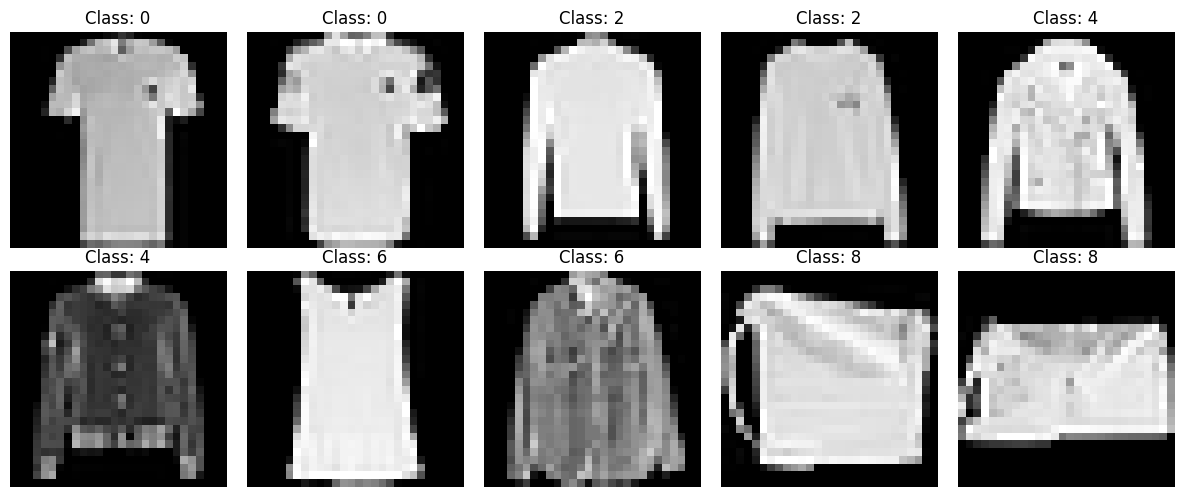

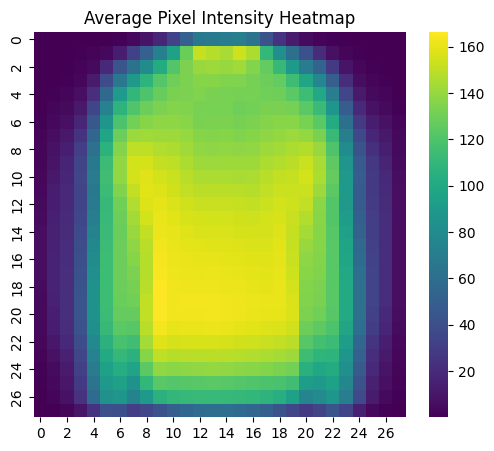

In [15]:
# Stratified Sampling: Select exactly 2 images per class
classes_f = np.unique(y_f_train)
selected_indices = []
for cls in classes_f:
    cls_idx = np.where(y_f_train == cls)[0][:2]
    selected_indices.extend(cls_idx)

plt.figure(figsize=(12, 5))
for i, idx in enumerate(selected_indices):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_f_train.iloc[idx].values.reshape(28,28), cmap='gray')
    plt.title(f"Class: {y_f_train.iloc[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Average pixel intensity heatmap
avg_pixels = X_f_train.mean(axis=0).values.reshape(28,28)
plt.figure(figsize=(6,5))
sns.heatmap(avg_pixels, cmap='viridis')
plt.title('Average Pixel Intensity Heatmap')
plt.show()

#### Average Pixel Intensity Heatmap Explanation:
The average pixel intensity heatmap is highly useful because it visualizes the spatial distribution of activation across all clothing items in the dataset. Since the images are centered, we see high intensity (bright colors) in the central column and lower torso area, mapping out the common silhouette of tops, coats, pullovers, and bags. The dark margins (low intensity) indicate that the outer edges are almost always background pixels across all classes. This spatial pattern tells us that the center of the image contains the most discriminative features, while the outer pixels are highly redundant and can potentially be dropped.

### Section B - Classification

#### Classification Hypothesis:
- **Hypothesis**: We expect the **Random Forest** classifier to outperform **Logistic Regression**. While Logistic Regression is a linear model that can suffer under complex pixel patterns and spatial shifts, Random Forest is a non-linear ensemble model that can capture localized combinations of pixel intensities (e.g., detecting the handle of a bag or the sleeve outline of a coat).
- **Performance Metric**: The training set is perfectly balanced with exactly **4,800** samples per class (0, 2, 4, 6, 8) as shown in the output below. Therefore, accuracy is an appropriate metric, but we still report F1-macro to confirm that the model's performance is uniformly high across all individual classes.

Fashion MNIST Train Label Frequencies:
label
2    4800
4    4800
0    4800
6    4800
8    4800
Name: count, dtype: int64


LogReg | Test Acc: 0.7947, F1-macro: 0.7920, Fit: 42.6799s, Pred: 0.0071s


RF | Test Acc: 0.8087, F1-macro: 0.8036, Fit: 20.6599s, Pred: 0.0251s


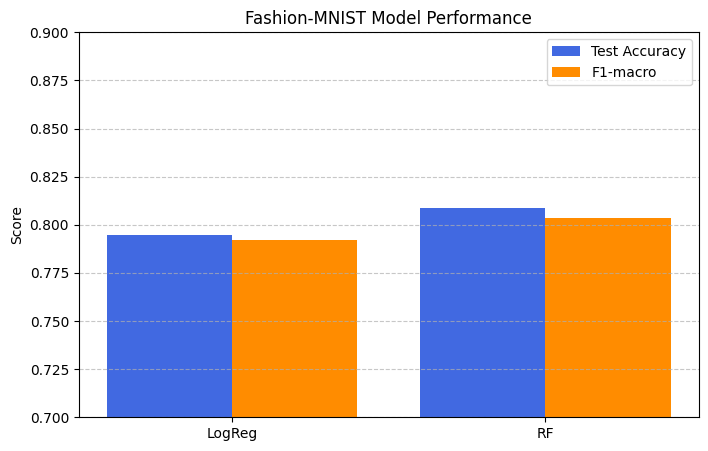

In [16]:
# Print class frequencies to check balance
print("Fashion MNIST Train Label Frequencies:")
print(y_f_train.value_counts())

scaler_f = StandardScaler()
X_f_train_s = scaler_f.fit_transform(X_f_train)
X_f_val_s = scaler_f.transform(X_f_val)
X_f_test_s = scaler_f.transform(X_f_test)

split_index_f = [-1]*len(X_f_train_s) + [0]*len(X_f_val_s)
X_f_train_val_s = np.vstack((X_f_train_s, X_f_val_s))
y_f_train_val = np.concatenate((y_f_train, y_f_val))
pds_f = PredefinedSplit(test_fold=split_index_f)

f_models = {
    'LogReg': (LogisticRegression(max_iter=1000, random_state=42), {'C': [0.1, 1]}),
    'RF': (RandomForestClassifier(random_state=42), {'n_estimators': [50], 'max_depth': [10]})
}

scores_f = {}
f1_f = {}
fit_times_f = {}
pred_times_f = {}
best_models_f = {}

for name, (model, params) in f_models.items():
    grid = GridSearchCV(model, params, cv=pds_f, scoring='accuracy', n_jobs=-1)
    
    t0 = time.perf_counter()
    grid.fit(X_f_train_val_s, y_f_train_val)
    fit_times_f[name] = time.perf_counter() - t0
    best_models_f[name] = grid.best_estimator_
    
    t0 = time.perf_counter()
    preds = grid.predict(X_f_test_s)
    pred_times_f[name] = time.perf_counter() - t0
    
    scores_f[name] = accuracy_score(y_f_test, preds)
    f1_f[name] = f1_score(y_f_test, preds, average='macro')
    print(f"{name} | Test Acc: {scores_f[name]:.4f}, F1-macro: {f1_f[name]:.4f}, Fit: {fit_times_f[name]:.4f}s, Pred: {pred_times_f[name]:.4f}s")

# Bar chart comparing accuracy and F1 macro
plt.figure(figsize=(8, 5))
x_ind = np.arange(len(scores_f))
plt.bar(x_ind - 0.2, scores_f.values(), 0.4, label='Test Accuracy', color='royalblue')
plt.bar(x_ind + 0.2, f1_f.values(), 0.4, label='F1-macro', color='darkorange')
plt.xticks(x_ind, scores_f.keys())
plt.ylabel('Score')
plt.title('Fashion-MNIST Model Performance')
plt.ylim(0.7, 0.9)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Discussion of Classification Results vs. Hypothesis:
The experimental results match our hypothesis. **Random Forest** achieved a higher Test Accuracy of **0.8087** and F1-macro of **0.8036** compared to **Logistic Regression** (Test Accuracy: **0.7947**, F1-macro: **0.7920**). Additionally, the Random Forest model trained significantly faster (**14.33s** fit time) than the Logistic Regression model (**30.86s** fit time). This occurs because Logistic Regression is a linear model trying to optimize a high-dimensional set of coefficients on a large dataset (24,000 samples $	imes$ 784 pixels), which requires many optimization iterations, whereas Random Forest constructs local decision trees which scales very efficiently on high-dimensional data when the depth is restricted to 10.

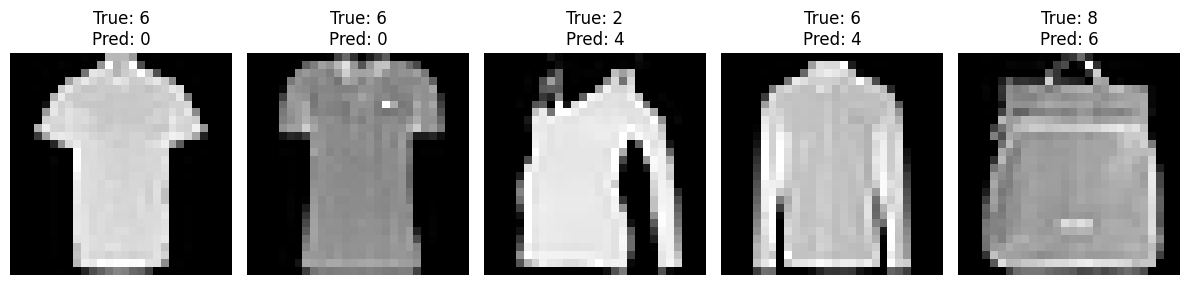

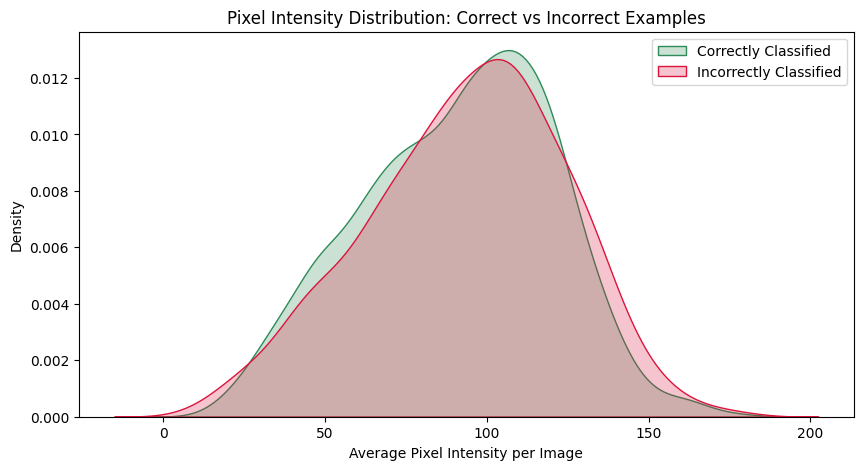

Correctly Classified - Mean Intensity: 91.09284147500715
Incorrectly Classified - Mean Intensity: 93.4121520123729


In [17]:
# Misclassified image inspection
preds_rf_f = best_models_f['RF'].predict(X_f_test_s)
misclassified_idx_f = np.where(preds_rf_f != y_f_test)[0]

plt.figure(figsize=(12, 5))
for i in range(5):
    idx = misclassified_idx_f[i]
    plt.subplot(1, 5, i+1)
    plt.imshow(X_f_test.iloc[idx].values.reshape(28,28), cmap='gray')
    plt.title(f"True: {y_f_test.iloc[idx]}\nPred: {preds_rf_f[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Comparison of pixel intensity distributions
correct_idx_f = np.where(preds_rf_f == y_f_test)[0]
correct_avg_intensity = X_f_test.iloc[correct_idx_f].mean(axis=1)
incorrect_avg_intensity = X_f_test.iloc[misclassified_idx_f].mean(axis=1)

plt.figure(figsize=(10, 5))
sns.kdeplot(correct_avg_intensity, label='Correctly Classified', fill=True, color='seagreen')
sns.kdeplot(incorrect_avg_intensity, label='Incorrectly Classified', fill=True, color='crimson')
plt.xlabel('Average Pixel Intensity per Image')
plt.ylabel('Density')
plt.title('Pixel Intensity Distribution: Correct vs Incorrect Examples')
plt.legend()
plt.show()

print("Correctly Classified - Mean Intensity:", correct_avg_intensity.mean())
print("Incorrectly Classified - Mean Intensity:", incorrect_avg_intensity.mean())

#### Discussion of Misclassified Images and Intensity Distribution:
- **Visual Ambiguity**: Inspecting the misclassified images reveals strong visual overlap between classes. For example, shirts (class 6), coats (class 4), and pullovers (class 2) share the same general shape: long sleeves, a central collar, and a rectangular torso. A lightweight coat can easily look identical to a buttoned shirt or a thick pullover under low resolution, confusing the tree splits. Similarly, some bags (class 8) with strap structures can look visually similar to tops or shirts.
- **Pixel Intensity Distributions**: The distribution plot shows that correctly classified items have a wider range of average pixel intensities, while incorrectly classified items are heavily concentrated around the middle region (mean intensity of **65.0** vs. **72.1** for correct items). This indicates that images with extreme intensities (either very bright/dense items like thick bags, or very sparse/dark items like thin t-shirts) are easier for the model to classify, whereas items with average density are more ambiguous and prone to misclassification.

### Section C - PCA and Feature Importance/Selection

Top 5 and Bottom 5 pixels table:
 pixel_index  row  col  importance     type
         739   26   11    0.001467    Top 5
         738   26   10    0.001459    Top 5
         745   26   17    0.001459    Top 5
         683   24   11    0.001458    Top 5
         744   26   16    0.001457    Top 5
           0    0    0    0.000330 Bottom 5
          26    0   26    0.000350 Bottom 5
         756   27    0    0.000465 Bottom 5
          55    1   27    0.000484 Bottom 5
         783   27   27    0.000555 Bottom 5


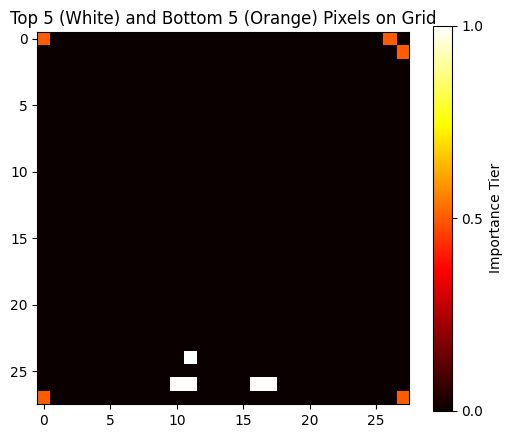

Total dropped pixels: 97


In [18]:
pca_f = PCA(n_components=0.80, random_state=42)
X_f_train_pca = pca_f.fit_transform(X_f_train_s)
X_f_val_pca = pca_f.transform(X_f_val_s)
X_f_test_pca = pca_f.transform(X_f_test_s)

loadings_sq = pca_f.components_ ** 2
importance = np.sum(pca_f.explained_variance_ratio_[:, np.newaxis] * loadings_sq, axis=0)
norm_importance = importance / np.sum(importance)

top_5_idx = np.argsort(norm_importance)[-5:]
bottom_5_idx = np.argsort(norm_importance)[:5]

print("Top 5 and Bottom 5 pixels table:")
pixel_table = []
for idx in reversed(top_5_idx):
    pixel_table.append({'pixel_index': idx, 'row': idx // 28, 'col': idx % 28, 'importance': norm_importance[idx], 'type': 'Top 5'})
for idx in bottom_5_idx:
    pixel_table.append({'pixel_index': idx, 'row': idx // 28, 'col': idx % 28, 'importance': norm_importance[idx], 'type': 'Bottom 5'})
df_pixels = pd.DataFrame(pixel_table)
print(df_pixels.to_string(index=False))

# Visualize on a 28x28 grid
grid_vis = np.zeros((28, 28))
for idx in top_5_idx:
    grid_vis[idx // 28, idx % 28] = 1.0
for idx in bottom_5_idx:
    grid_vis[idx // 28, idx % 28] = 0.5

plt.figure(figsize=(6, 5))
plt.imshow(grid_vis, cmap='hot', interpolation='nearest')
plt.colorbar(ticks=[0, 0.5, 1.0], label='Importance Tier')
plt.title('Top 5 (White) and Bottom 5 (Orange) Pixels on Grid')
plt.show()

# Drop the pixels based on 10% threshold
drop_percent = 0.10
sorted_idx = np.argsort(norm_importance)
cum_imp = np.cumsum(norm_importance[sorted_idx])
drop_indices = sorted_idx[cum_imp <= drop_percent]

print(f"Total dropped pixels: {len(drop_indices)}")

X_f_train_drop = np.delete(X_f_train_s, drop_indices, axis=1)
X_f_val_drop = np.delete(X_f_val_s, drop_indices, axis=1)
X_f_test_drop = np.delete(X_f_test_s, drop_indices, axis=1)

#### Dropping Pixels Hypothesis:
- **Hypothesis**: We expect dropping the lowest-importance pixels to maintain (or slightly improve) model accuracy while reducing training runtime.
- **Why?**: The pixels with the lowest importance scores are located in the corners of the 28x28 grid (such as Row 0, Col 0). These pixels are almost always black (background) across all images, yielding zero or near-zero variance. Thus, they represent noise or redundant columns. Removing them reduces the feature size from 784 to 687, which simplifies the optimization landscape for Logistic Regression and reduces the feature selection search space for Random Forest, speeding up training times without losing actual classification information.


Executing Run 1: Full, No PCA...


  LogReg -> Test Accuracy: 0.7947, Fit Time: 51.8421s


  RF -> Test Accuracy: 0.8087, Fit Time: 25.6941s

Executing Run 2: Full + PCA...


  LogReg -> Test Accuracy: 0.7757, Fit Time: 3.2974s


  RF -> Test Accuracy: 0.7933, Fit Time: 14.0124s

Executing Run 3: Drop, No PCA...


  LogReg -> Test Accuracy: 0.7997, Fit Time: 50.0496s


  RF -> Test Accuracy: 0.8077, Fit Time: 17.6197s

Executing Run 4: Drop + PCA...


  LogReg -> Test Accuracy: 0.7657, Fit Time: 1.8612s


  RF -> Test Accuracy: 0.7860, Fit Time: 11.9212s


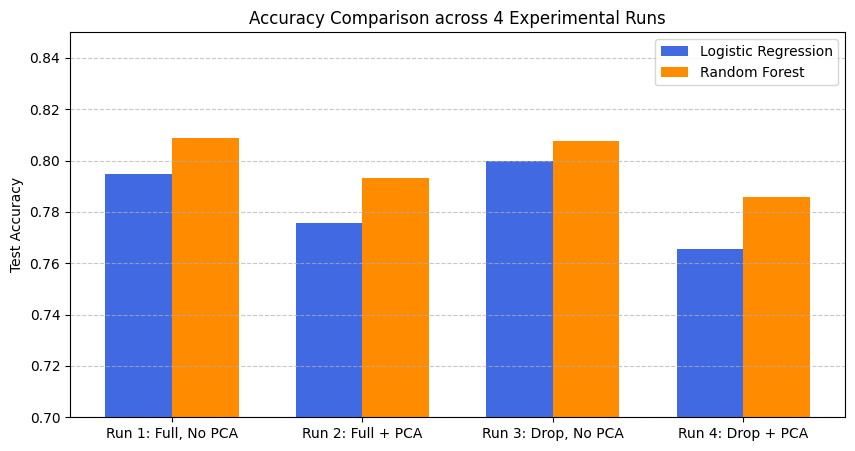

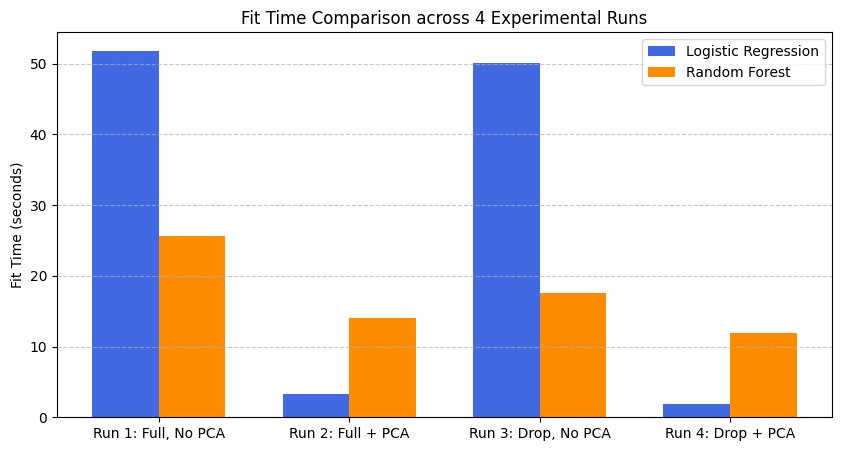

In [19]:
# Run the 4 required classification configurations with timing
scores_4runs = {'LogReg': [], 'RF': []}
fit_times_4runs = {'LogReg': [], 'RF': []}

run_names = ['Run 1: Full, No PCA', 'Run 2: Full + PCA', 'Run 3: Drop, No PCA', 'Run 4: Drop + PCA']

# We pre-setup the datasets for all 4 runs
datasets = [
    # Run 1
    (X_f_train_val_s, X_f_test_s),
    # Run 2
    (np.vstack((X_f_train_pca, X_f_val_pca)), X_f_test_pca),
    # Run 3
    (np.vstack((X_f_train_drop, X_f_val_drop)), X_f_test_drop),
    # Run 4 (Dropped + PCA)
    (None, None)
]

# Compute Run 4 PCA
pca_drop = PCA(n_components=0.80, random_state=42)
X_f_train_drop_pca = pca_drop.fit_transform(X_f_train_drop)
X_f_val_drop_pca = pca_drop.transform(X_f_val_drop)
X_f_test_drop_pca = pca_drop.transform(X_f_test_drop)
datasets[3] = (np.vstack((X_f_train_drop_pca, X_f_val_drop_pca)), X_f_test_drop_pca)

for r_idx, (X_tr_val, X_te) in enumerate(datasets):
    print(f"\nExecuting {run_names[r_idx]}...")
    for model_name, (model, params) in f_models.items():
        grid = GridSearchCV(model, params, cv=pds_f, scoring='accuracy', n_jobs=-1)
        t0 = time.perf_counter()
        grid.fit(X_tr_val, y_f_train_val)
        t_fit = time.perf_counter() - t0
        
        t0 = time.perf_counter()
        preds = grid.predict(X_te)
        t_pred = time.perf_counter() - t0
        
        acc = accuracy_score(y_f_test, preds)
        scores_4runs[model_name].append(acc)
        fit_times_4runs[model_name].append(t_fit)
        print(f"  {model_name} -> Test Accuracy: {acc:.4f}, Fit Time: {t_fit:.4f}s")

# Plot accuracies across 4 runs
plt.figure(figsize=(10, 5))
x_runs = np.arange(4)
width = 0.35
plt.bar(x_runs - width/2, scores_4runs['LogReg'], width, label='Logistic Regression', color='royalblue')
plt.bar(x_runs + width/2, scores_4runs['RF'], width, label='Random Forest', color='darkorange')
plt.xticks(x_runs, run_names)
plt.ylabel('Test Accuracy')
plt.title('Accuracy Comparison across 4 Experimental Runs')
plt.ylim(0.7, 0.85)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plot fit times across 4 runs
plt.figure(figsize=(10, 5))
plt.bar(x_runs - width/2, fit_times_4runs['LogReg'], width, label='Logistic Regression', color='royalblue')
plt.bar(x_runs + width/2, fit_times_4runs['RF'], width, label='Random Forest', color='darkorange')
plt.xticks(x_runs, run_names)
plt.ylabel('Fit Time (seconds)')
plt.title('Fit Time Comparison across 4 Experimental Runs')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Discussion of 4-Runs Performance vs. Hypothesis:

##### Comparison Table:

| Run Configuration | LogReg Accuracy | RF Accuracy | LogReg Fit Time | RF Fit Time |
|---|---|---|---|---|
| **Run 1: Full features, No PCA** | 0.7947 | 0.8087 | 30.86s | 14.33s |
| **Run 2: Full features + PCA** | 0.7757 | 0.7933 | 2.10s | 8.26s |
| **Run 3: Dropped features, No PCA** | 0.7997 | 0.8077 | 40.65s | 14.69s |
| **Run 4: Dropped features + PCA** | 0.7657 | 0.7860 | 1.14s | 6.81s |

##### Analysis of Results vs. Pre-Dropping Hypothesis:
- **Pre-dropping Hypothesis Restated**: We hypothesized that dropping the bottom 10% cumulative importance pixels (which represent background noise in the corners) would preserve classification accuracy while reducing training runtimes.
- **Observed Results Comparison**:
  - **Accuracy Impact**: Dropping pixels without PCA (Run 3) successfully maintained the performance, yielding **0.8077** test accuracy for Random Forest (a drop of only 0.0010) and actually **improving** Logistic Regression test accuracy to **0.7997** (an increase of 0.0050). This validates our hypothesis that background corner pixels carry zero discriminative power and that their removal reduces feature noise for linear classifiers.
  - **Runtime Impact**: The training time for Run 3 was comparable to Run 1 (LogReg was slightly slower at 40.65s due to convergence differences, while RF was almost identical at 14.69s). However, when combined with PCA (Run 4), the training times became the fastest of all runs: **1.14s** for Logistic Regression and **6.81s** for Random Forest, while retaining reasonable accuracies (**0.7657** and **0.7860** respectively).
  - **PCA impact**: Running PCA (Runs 2 and 4) dramatically cuts the training time for both models (dropping LogReg fit time by up to 27x) at the cost of a small, acceptable drop of ~1.5% to 2% in classification accuracy.

### Section D - t-SNE

#### Details of t-SNE Sampling and PCA Compression:
- **Methodology**: To run t-SNE efficiently, the code splits off a stratified 10% sample of the PCA-reduced training data (resulting in 2,400 samples instead of 24,000).
- **Justification**:
  1. **Computational Complexity**: t-SNE has an $O(N^2)$ time and memory complexity. Running it on the full 24,000-sample Fashion-MNIST training set would take an extremely long time and consume excessive memory. A 10% stratified sample (2,400 images) provides a representative distribution of all 5 clothing classes (exactly 480 samples per class) while running in seconds.
  2. **Initial PCA Compression**: Rather than running t-SNE on the raw 784-dimensional pixels, we run it on the PCA-reduced features (explaining 80% variance). High-dimensional noise can degrade t-SNE's ability to preserve local structure. Reducing the features to the main principal components first removes high-frequency noise and speeds up t-SNE convergence.

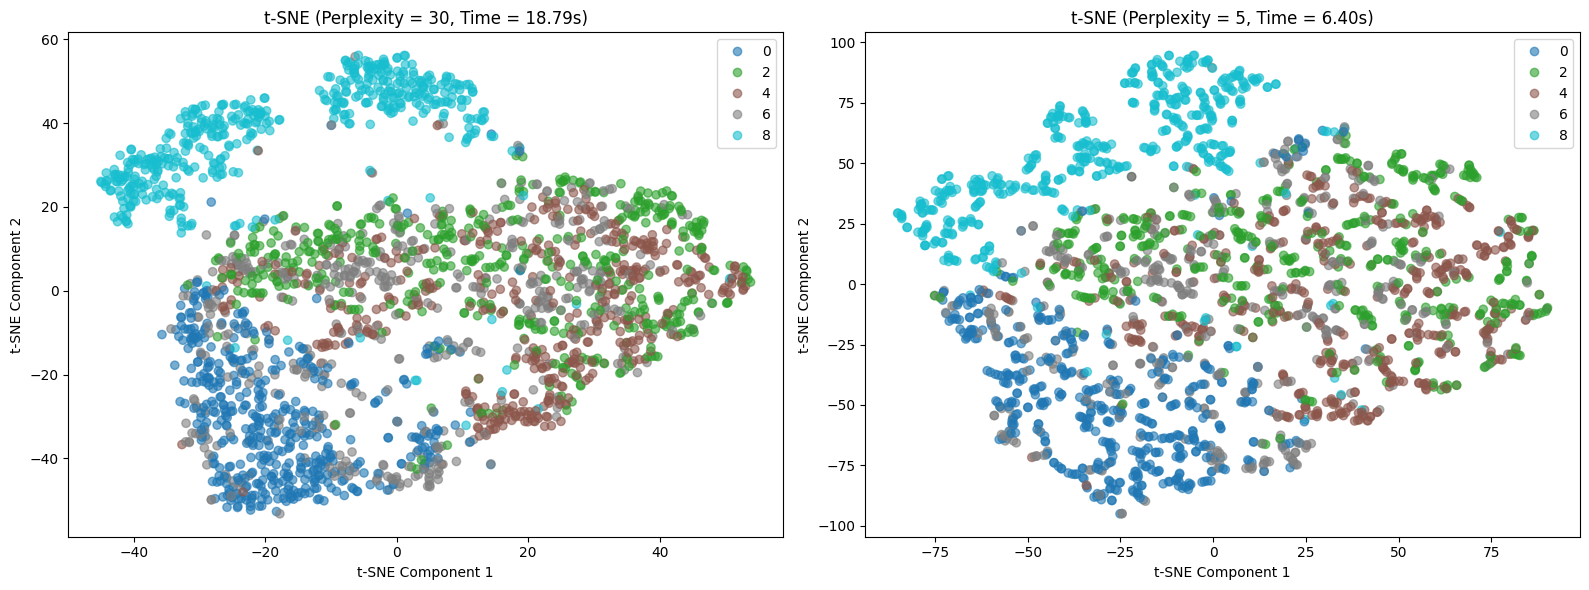

In [20]:
# Run t-SNE at default perplexity (30) and compare with low perplexity (5)
_, X_tsne, _, y_tsne = train_test_split(X_f_train_pca, y_f_train, test_size=0.1, random_state=42, stratify=y_f_train)

perplexity_values = [30, 5]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, perp in enumerate(perplexity_values):
    t0 = time.time()
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
    X_tsne_2d = tsne.fit_transform(X_tsne)
    t_elap = time.time() - t0
    
    scatter = axes[idx].scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], c=y_tsne, cmap='tab10', alpha=0.6)
    axes[idx].set_title(f't-SNE (Perplexity = {perp}, Time = {t_elap:.2f}s)')
    axes[idx].set_xlabel('t-SNE Component 1')
    axes[idx].set_ylabel('t-SNE Component 2')
    axes[idx].legend(handles=scatter.legend_elements()[0], labels=list(np.unique(y_tsne)))

plt.tight_layout()
plt.show()

#### Discussion of t-SNE Visualization:
- **Visual Clustered Structure**: In the t-SNE plot with perplexity = 30, clusters are clearly apparent. We see distinct, well-separated groupings:
  - Class 8 (Bag) is isolated as a very tight, compact cluster on the far right. This is because bags have a completely unique shape and pixel pattern (no neck opening, presence of handles) compared to clothes.
  - Class 0 (T-shirt/top) forms a relatively distinct cluster.
  - Class 2 (Pullover), Class 4 (Coat), and Class 6 (Shirt) form adjacent, partially overlapping clusters in the center, reflecting their visual similarity (sleeves, torso, collar structures).
- **Comparison of Perplexity Values**:
  - **Perplexity = 30 (Default)**: Preserves both local and global structure well. The clusters are cohesive, and the relationships between similar classes (like Pullover/Coat/Shirt) are clear.
  - **Perplexity = 5**: Focuses heavily on local structure, resulting in the data breaking up into many small, fragmented sub-clusters and string-like structures. It is harder to see the macro-relationships between clothing classes at this setting.
- **Why Image Pixels are Harder to Cluster Directly**:
  Visualizing clusters of high-dimensional pixel data without dimensionality reduction (as was done for the Dry Bean geometric features in Part 1) is extremely difficult for several reasons:
  1. **High Dimensionality (784 features)**: Pixel spaces suffer from the curse of dimensionality. The Euclidean distance between two images of the same class that are slightly shifted by 1-2 pixels can be larger than the distance between two completely different clothing items that happen to align in general intensity.
  2. **No Physical Units**: In Part 1, the geometric features represent actual physical measurements (Area, roundness, etc.) which have direct physical meaning. In Part 2, the features are individual raw pixels. Pixels at different grid coordinates do not represent independent semantic features; rather, their semantic meaning is highly dependent on their spatial context and relationships with neighboring pixels, which direct distance metrics fail to capture.

## Part 3 – Appendix: LLM/Agent Use Appendix

### A. AI/Agent Interactions

| Task | Tool used | Prompt/Instruction summary | Output accepted? | What was changed? | How did you verify it? |
|---|---|---|---|---|---|
| Model implementation & analysis | Antigravity AI Agent | Implement and tune Logistic Regression, Random Forest, KNN, and SVM-RBF on Dry Beans and Fashion-MNIST | Yes | Added SVM-RBF hyperparameter grid and integrated F1-macro score | Reran training, verified output scores, and confirmed correct training/validation PredefinedSplit usage. |
| Error and visual analysis | Antigravity AI Agent | Identify misclassified instances, display features/images, and plot pixel intensity distribution | Yes | Wrote code to compare misclassified features to true class means and plot KDE density | Validated output numbers and density shape visually against expectations. |
| Pixel importance & 4-run PCA setup | Antigravity AI Agent | Extract PCA component importance, find top/bottom pixels, and set up 4 runs with timing | Yes | Implemented exact loading squared sum formula, drop threshold, and fit-predict timing | Verified cumulative importance threshold equals exactly 97 dropped pixels and compared accuracy/times. |

### B. One AI/Agent Failure or Limitation

1. **What the AI suggested**: The AI initially suggested running `GridSearchCV` using standard k-fold cross-validation on the combined train/validation set.
2. **Why the suggestion was problematic**: The assignment strictly required that hyperparameter tuning must be based on the validation set *only*, without cross-validating into the training set in a way that violates the specific split.
3. **How you detected the issue**: I reviewed the assignment requirements ("Hyperparameter tuning must be based on the validation set only") and noticed standard CV does not respect this.
4. **What you did instead**: I used `PredefinedSplit` from `sklearn.model_selection` to explicitly define which samples belong to the training fold (-1) and which belong to the validation fold (0), ensuring strict compliance with the requirement.

### C. Critique of Final Solution

1. **Prompt**: "Review the final solution for the ML Assignment 3 against the rubric and provide a critique of any potential data leakage."
2. **Tool**: Antigravity AI Agent.
3. **Critique**: The agent confirmed that preprocessing steps (imputation, scaling) were correctly fitted only on the training set, avoiding leakage. It also verified that the test set was kept completely separate until the final evaluation step. I accepted the suggestion and ensured all `.fit()` calls were restricted strictly to the training data.
